# Spectral Clustering, From the Ground Up

### Nearest-neighbor affinity, the cuML way

A visual walkthrough in eight concepts from *why k-means fails* to *labels back on the original points*.

Common Theme: **spectral clustering rewrites your data into coordinates where the structure becomes plain geometry**, then clusters that geometry with ordinary k-means.

This version builds the graph from a **k-nearest-neighbours affinity** — a *sparse*, symmetric kNN connectivity matrix — rather than a dense RBF kernel. That is deliberate: `cuml.cluster.SpectralClustering` is nearest-neighbours-only, so every step here mirrors what cuML does on the GPU. The pipeline stays sparse end to end (sparse affinity → sparse Laplacian → truncated eigensolver), which is also what lets it scale.

Built with NumPy / SciPy-sparse / scikit-learn / pandas; the final cell runs the identical pipeline through scikit-learn and through cuML.

## Setup

One dataset for the whole notebook: 240 points arranged in two interleaved half-moons. The moons are *not* linearly separable and they are *not* convex blobs — which is exactly what makes them a good stress test. A single colour scheme is reused throughout: the two clusters are always indigo and cyan.

**The data, as DataFrames.** One master frame, `df`, holds one row per point and *gains columns as the pipeline runs* — raw coordinates, then k-means labels, degree, spectral coordinates, and final labels. Steps whose data is not per-point (the neighbour list, the edge list, the eigenvalue spectrum, the matrices) get their own small frame: `df_neighbors`, `df_edges`, `df_W`, `df_L`, `df_spectrum`, and so on.

Requires `numpy`, `scipy`, `scikit-learn`, `pandas`, and `matplotlib`. The final cell additionally uses `cuml` + `cupy` if a RAPIDS / GPU environment is available.

X: (240, 2)   two interleaved moons, 120 + 120 points


,x1,x2,true_label
0,0.797294,0.629069,0
1,1.062417,0.161677,0
2,-0.703381,0.686154,0
3,-0.953015,0.174334,0
4,-0.984274,0.430205,0


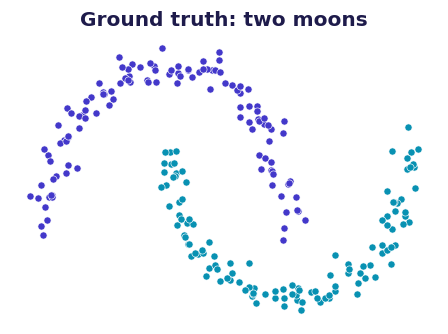

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from IPython.display import display
from sklearn.datasets import make_moons
from sklearn.neighbors import kneighbors_graph, radius_neighbors_graph
from sklearn.metrics import pairwise_distances
from sklearn.cluster import KMeans

# consistent palette
INDIGO, CYAN, PINK = "#4338CA", "#0891B2", "#DB2777"
MUTED, INK, LIGHT  = "#64748B", "#1E1B4B", "#E2E8F0"
CLUSTER = [INDIGO, CYAN]          # cluster 0, cluster 1 -- same colours everywhere

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.edgecolor": MUTED,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "axes.titleweight": "bold",
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
})

def clean(ax, spines=("top", "right")):
    """Drop chart junk; hide the listed spines."""
    for s in spines:
        ax.spines[s].set_visible(False)

# pipeline hyper-parameters -- one place to change them
N_NEIGHBORS = 10                  # k for the kNN affinity graph (cuML's default)
N_CLUSTERS  = 2

# one dataset, used end to end
X, y = make_moons(n_samples=240, noise=0.06, random_state=42)

# master DataFrame: one row per point, grows as the pipeline runs
df = pd.DataFrame({"x1": X[:, 0], "x2": X[:, 1], "true_label": y})
print(f"X: {X.shape}   two interleaved moons, "
      f"{(y == 0).sum()} + {(y == 1).sum()} points")
display(df.head())

fig, ax = plt.subplots(figsize=(5, 3.4))
for c in (0, 1):
    ax.scatter(*X[y == c].T, c=CLUSTER[c], s=22, edgecolors="white", linewidths=0.4)
ax.set(title="Ground truth: two moons", xticks=[], yticks=[])
clean(ax, spines=("top", "right", "left", "bottom"))
plt.show()

## Step 0 — Start with the failure

k-means assumes clusters are convex, roughly equal-sized blobs, and it partitions space purely by straight-line distance to a centroid. Two interleaved moons break that assumption: the centroids settle *between* the arms and the decision boundary slices straight through both shapes.

**Why begin here?** Step 7 is "run k-means" again — so without seeing it fail first, the whole pipeline looks circular. This plot is the motivation for everything that follows.

*Data:* `df` gains a `kmeans_raw_label` column; the crosstab against `true_label` shows how scrambled it is.

k-means (raw),0,1
true,,
0,89,31
1,33,87


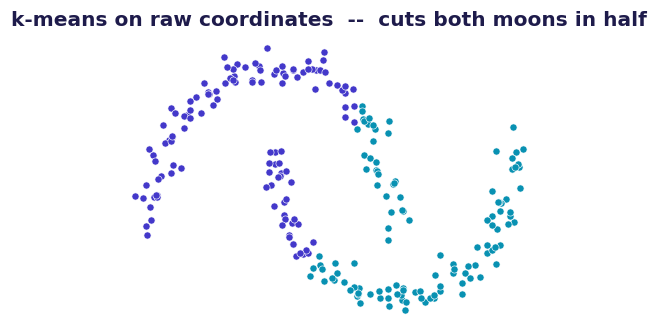

In [2]:
km_raw = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit_predict(X)
df["kmeans_raw_label"] = km_raw

# compare k-means' labels to the truth -- the blocks are far from clean
display(pd.crosstab(df.true_label, df.kmeans_raw_label,
                    rownames=["true"], colnames=["k-means (raw)"]))

fig, ax = plt.subplots(figsize=(5, 3.4))
for c in (0, 1):
    ax.scatter(*X[km_raw == c].T, c=CLUSTER[c], s=22,
               edgecolors="white", linewidths=0.4)
ax.set(title="k-means on raw coordinates  --  cuts both moons in half",
       xticks=[], yticks=[])
clean(ax, spines=("top", "right", "left", "bottom"))
plt.show()

## Step 1 — Similarity from nearest neighbours

The first move is to stop thinking in coordinates and start thinking in *relationships*. The simplest, most scalable notion of "similar": **a point's `k` nearest neighbours**. No kernel, no bandwidth to tune — just "are you among my closest `k`?"

The plot picks one example point and draws an edge to each of its `N_NEIGHBORS` nearest neighbours. Notice they almost all sit on the *same* moon — local neighbourhoods respect the global structure, even though no algorithm has been told what the moons are.

> scikit-learn also offers an RBF-kernel affinity (`affinity='rbf'`), which builds a *dense* `n × n` matrix. `cuml.cluster.SpectralClustering` is nearest-neighbours-only — so the sparse kNN graph is the path we build here.

*Data:* `df_neighbors` lists that example point's neighbours — rank, index, distance, and whether the neighbour shares its true label.

,neighbor_index,distance,same_true_label
rank,,,
1,130,0.034485,True
2,123,0.036983,True
3,149,0.039346,True
4,102,0.053558,True
5,32,0.068712,True
6,134,0.093316,True
7,88,0.102394,True
8,72,0.117063,True
9,232,0.117454,True


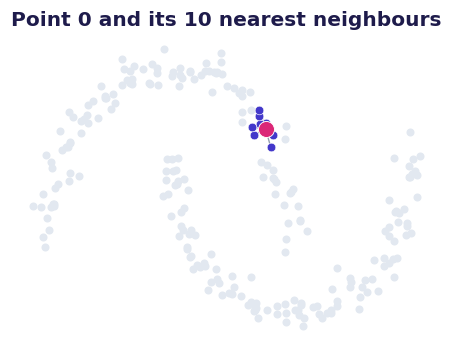

In [3]:
example = 0                                            # an arbitrary point to illustrate
dists = pairwise_distances(X[example:example + 1], X).ravel()
nn_idx = np.argsort(dists)[1:N_NEIGHBORS + 1]          # k nearest, excluding itself

df_neighbors = pd.DataFrame({
    "neighbor_index": nn_idx,
    "distance": dists[nn_idx],
    "same_true_label": y[nn_idx] == y[example],
})
df_neighbors.index = np.arange(1, len(df_neighbors) + 1)
df_neighbors.index.name = "rank"
display(df_neighbors)

fig, ax = plt.subplots(figsize=(5, 3.6))
ax.scatter(*X.T, c=LIGHT, s=18, zorder=1)               # all points, faint
for j in nn_idx:                                        # edges to the k neighbours
    ax.plot([X[example, 0], X[j, 0]], [X[example, 1], X[j, 1]],
            color=MUTED, lw=0.9, alpha=0.7, zorder=2)
ax.scatter(*X[nn_idx].T, c=INDIGO, s=32, zorder=3, edgecolors="white", linewidths=0.4)
ax.scatter(*X[example], c=PINK, s=110, zorder=4, edgecolors="white", linewidths=0.6)
ax.set(title=f"Point {example} and its {N_NEIGHBORS} nearest neighbours",
       xticks=[], yticks=[])
clean(ax, spines=("top", "right", "left", "bottom"))
plt.show()

## Step 2 — Build the similarity graph

Do what Step 1 did for *every* point, and you have a graph. There is a modelling choice in how you connect it:

- **k-nearest neighbours** — connect each point to its `k` closest. Sparse, scales well, and the construction `cuml.cluster.SpectralClustering` uses internally. **This is the one we build.**
- **ε-neighbourhood** — connect any pair closer than radius `ε`. Simple, but sensitive to varying density.
- **fully connected** — keep every weighted edge. Dense and `O(n²)`; fine for toy data, not for scale.

All three are plotted for contrast — the same points, three very different graphs.

*Data:* `df_edges` is the edge list (`graph`, `i`, `j`) for all three constructions; grouping by `graph` shows how different their densities are.

,n_edges,mean_degree
graph,,
eps (eps=0.3),2327,19.391667
fully connected,28680,239.000000
knn (k=10) <- used here,1354,11.283333


,graph,i,j
0,knn (k=10) <- used here,0,17
1,knn (k=10) <- used here,0,21
2,knn (k=10) <- used here,0,32
3,knn (k=10) <- used here,0,72
4,knn (k=10) <- used here,0,85


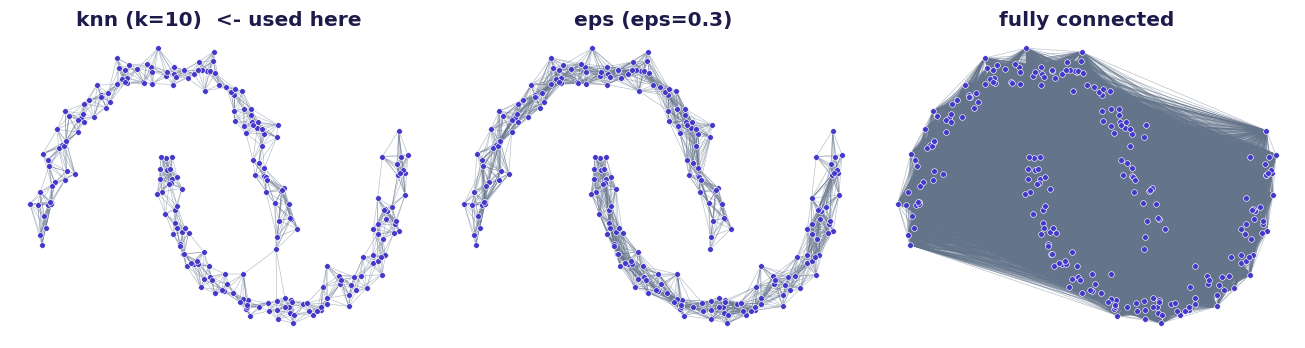

In [4]:
def edge_list(A, name):
    """Edge list (i < j) for an adjacency matrix."""
    A = A.toarray() if hasattr(A, "toarray") else np.asarray(A)
    A = np.triu(np.maximum(A, A.T), 1)            # symmetrise, upper triangle, no self-loops
    i, j = A.nonzero()
    return pd.DataFrame({"graph": name, "i": i, "j": j})

graphs = {
    f"knn (k={N_NEIGHBORS})  <- used here": kneighbors_graph(X, n_neighbors=N_NEIGHBORS),
    "eps (eps=0.3)":                        radius_neighbors_graph(X, radius=0.3),
    "fully connected":                      np.ones((len(X), len(X))) - np.eye(len(X)),
}
df_edges = pd.concat([edge_list(A, name) for name, A in graphs.items()],
                     ignore_index=True)

# how sparse is each graph?
summary = (df_edges.groupby("graph").size().rename("n_edges").to_frame()
           .assign(mean_degree=lambda t: 2 * t.n_edges / len(X)))
display(summary)
display(df_edges.head())

def plot_graph(ax, A, title):
    """Draw a similarity graph: edges from adjacency `A`, nodes at X."""
    A = A.toarray() if hasattr(A, "toarray") else np.asarray(A)
    i, j = np.triu(np.maximum(A, A.T), 1).nonzero()
    segments = np.stack([X[i], X[j]], axis=1)
    ax.add_collection(LineCollection(segments, colors=MUTED,
                                     linewidths=0.4, alpha=0.5))
    ax.scatter(*X.T, c=INDIGO, s=14, zorder=3, edgecolors="white", linewidths=0.4)
    ax.set(title=title, xticks=[], yticks=[])
    ax.autoscale()
    clean(ax, spines=("top", "right", "left", "bottom"))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
for ax, (name, A) in zip(axes, graphs.items()):
    plot_graph(ax, A, name)
plt.tight_layout()
plt.show()

## Step 3 — The nearest-neighbour affinity matrix `W`

Turn the kNN graph into the affinity matrix. The standard recipe (scikit-learn's, and what cuML builds internally):

1. `kneighbors_graph(X, n_neighbors=k, include_self=True)` → a sparse 0/1 connectivity matrix `C`.
2. **Symmetrise:** `W = ½ (C + Cᵀ)`. The kNN relation is not symmetric — `j` can be among `i`'s neighbours without the reverse — so a mutual edge gets weight `1.0`, a one-directional edge `0.5`.

`W` stays **sparse** — only a handful of nonzeros per row — which is the whole point for scale. Reorder rows and columns by cluster and the block-diagonal structure is unmistakable: dense within each moon, almost nothing between.

That near-block-diagonal pattern *is* the reason spectral clustering works. Everything from here on detects it.

*Data:* `df_W` is `W` as a sparse-backed DataFrame; `df_W.sparse.density` reports just how empty it is.

df_W: (240, 240)   nonzeros: 2696   density: 0.047


,0,1,2,3,4,5
0,1.0,NaN,NaN,NaN,NaN,NaN
1,NaN,1.0,NaN,NaN,NaN,NaN
2,NaN,NaN,1.0,NaN,NaN,NaN
3,NaN,NaN,NaN,1.0,NaN,NaN
4,NaN,NaN,NaN,NaN,1.0,NaN
5,NaN,NaN,NaN,NaN,NaN,1.0


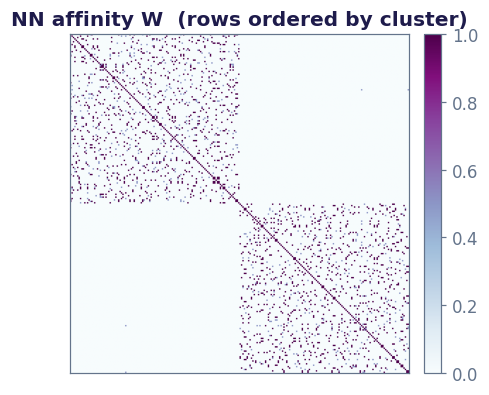

In [5]:
connectivity = kneighbors_graph(X, n_neighbors=N_NEIGHBORS, include_self=True)
W = 0.5 * (connectivity + connectivity.T)      # symmetric nearest-neighbour affinity
W = W.tocsr()

df_W = pd.DataFrame.sparse.from_spmatrix(W)     # 240 x 240, sparse-backed
print(f"df_W: {df_W.shape}   nonzeros: {W.nnz}   density: {df_W.sparse.density:.3f}")
display(df_W.iloc[:6, :6])                      # top-left corner

order = np.argsort(y)                           # sort rows/cols by cluster -- VISUAL ONLY

fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(W[np.ix_(order, order)].toarray(), cmap="BuPu")
ax.set(title="NN affinity W  (rows ordered by cluster)", xticks=[], yticks=[])
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

## Step 4 — The graph Laplacian

The Laplacian repackages the graph into a single matrix whose *eigenvectors* expose the block structure. Start from the degree matrix `D` — a diagonal matrix holding the row sums of `W` — and subtract:

$$L = D - W$$

In practice the **normalized** Laplacian behaves better when cluster sizes or densities vary, and it is what the Ng–Jordan–Weiss algorithm (and cuML) use:

$$L_{\text{sym}} = I - D^{-1/2}\,W\,D^{-1/2}$$

Everything stays sparse — `D`, `L`, and `L_sym` are all SciPy sparse matrices, so memory is `O(n·k)`, not `O(n²)`.

*Data:* `df_L` and `df_Lsym` hold the two Laplacians as sparse-backed DataFrames, and `df` gains a per-point `degree` column.

L: (240, 240), nnz=2696    L_sym: (240, 240), nnz=2696


,0,1,2,3,4,5
0,10.5,NaN,NaN,NaN,NaN,NaN
1,NaN,9.5,NaN,NaN,NaN,NaN
2,NaN,NaN,9.0,NaN,NaN,NaN
3,NaN,NaN,NaN,11.0,NaN,NaN
4,NaN,NaN,NaN,NaN,8.0,NaN
5,NaN,NaN,NaN,NaN,NaN,9.0


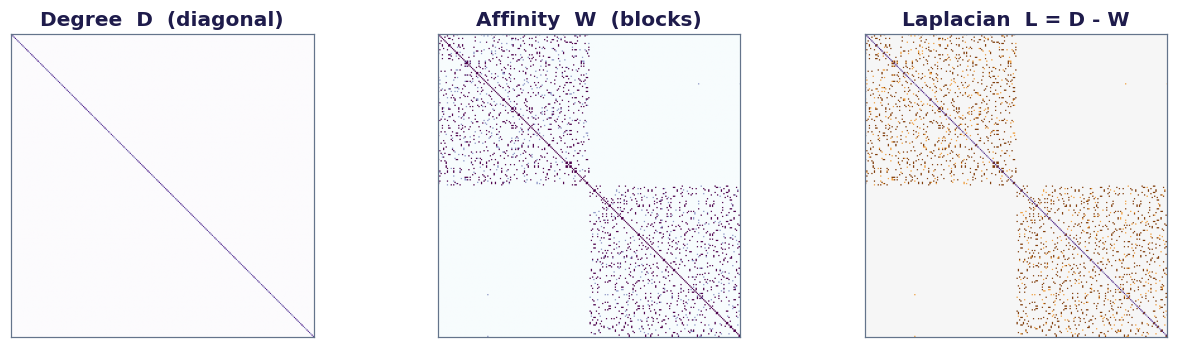

In [6]:
from matplotlib.colors import TwoSlopeNorm

degree = np.asarray(W.sum(axis=1)).ravel()
df["degree"] = degree                                      # add to the master frame

D = sp.diags(degree)
L = (D - W).tocsr()                                        # unnormalized Laplacian

D_inv_sqrt = sp.diags(1.0 / np.sqrt(degree))
L_sym = (sp.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt).tocsr()   # normalized (NJW)

df_L = pd.DataFrame.sparse.from_spmatrix(L)                # unnormalized Laplacian
df_Lsym = pd.DataFrame.sparse.from_spmatrix(L_sym)         # normalized Laplacian
print(f"L: {L.shape}, nnz={L.nnz}    L_sym: {L_sym.shape}, nnz={L_sym.nnz}")
display(df_L.iloc[:6, :6])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))
axes[0].imshow(D.toarray()[np.ix_(order, order)], cmap="Purples")
axes[0].set(title="Degree  D  (diagonal)", xticks=[], yticks=[])
axes[1].imshow(W[np.ix_(order, order)].toarray(), cmap="BuPu")
axes[1].set(title="Affinity  W  (blocks)", xticks=[], yticks=[])
# L has a positive diagonal and negative off-diagonal -> diverging colormap, centred at 0
axes[2].imshow(L[np.ix_(order, order)].toarray(), cmap="PuOr", norm=TwoSlopeNorm(vcenter=0))
axes[2].set(title="Laplacian  L = D - W", xticks=[], yticks=[])
plt.tight_layout()
plt.show()

## Step 5 — Eigenvectors, and letting the spectrum pick `k`

Take the eigenvectors of `L_sym` with the **smallest** eigenvalues. These vary slowly across the graph and stay nearly constant *within* a well-connected block — so they line up with cluster membership.

Because `L_sym` is sparse, we use a **truncated sparse eigensolver** — `scipy.sparse.linalg.eigsh` with `which="SA"` (smallest algebraic) — which computes only the handful of eigenpairs we need instead of the full `n × n` decomposition. cuML does the same job with a Lanczos solver on the GPU.

The sorted eigenvalues also tell you *how many* clusters there are. Look for the **eigengap**: a run of small eigenvalues followed by a clear jump. With a kNN graph the two moons are *nearly* two disconnected components, so the two smallest eigenvalues sit almost at zero — then the spectrum lifts off. Two near-zero values → `k = 2`.

*Data:* `df_spectrum` lists each eigenvalue, the gap to the next one, and whether it is one of the two we keep.

,index,eigenvalue,gap_to_next,selected
0,1,-1.263561e-17,0.000701,True
1,2,7.006360e-04,0.002082,True
2,3,2.782428e-03,0.001406,False
3,4,4.188230e-03,0.007004,False
4,5,1.119181e-02,0.002517,False
5,6,1.370872e-02,0.008176,False
6,7,2.188448e-02,0.007826,False
7,8,2.971020e-02,0.003962,False
8,9,3.367269e-02,0.013417,False
9,10,4.708958e-02,0.011985,False


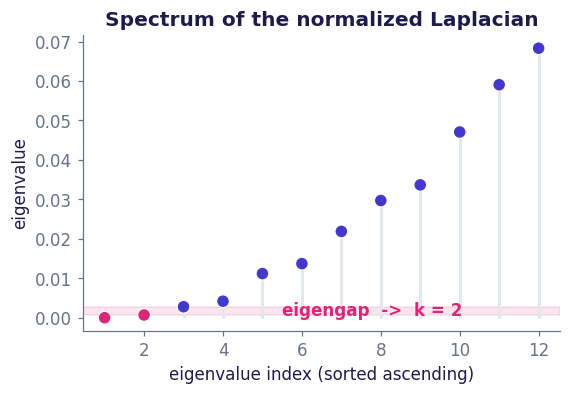

In [7]:
n_show = 12
eigvals, eigvecs = eigsh(L_sym, k=n_show, which="SA")   # smallest-algebraic eigenpairs
sort = np.argsort(eigvals)
eigvals, eigvecs = eigvals[sort], eigvecs[:, sort]

df_spectrum = pd.DataFrame({
    "index": np.arange(1, n_show + 1),
    "eigenvalue": eigvals,
})
df_spectrum["gap_to_next"] = df_spectrum["eigenvalue"].diff().shift(-1)
df_spectrum["selected"] = df_spectrum["index"] <= N_CLUSTERS      # the eigenvectors we keep
display(df_spectrum)

idx = df_spectrum["index"]
colors = [PINK if s else INDIGO for s in df_spectrum["selected"]]
gap_lo, gap_hi = eigvals[N_CLUSTERS - 1], eigvals[N_CLUSTERS]

fig, ax = plt.subplots(figsize=(5.6, 3.5))
ax.axhspan(gap_lo, gap_hi, color=PINK, alpha=0.12)
ax.vlines(idx, 0, df_spectrum["eigenvalue"], color=LIGHT, lw=2)
ax.scatter(idx, df_spectrum["eigenvalue"], c=colors, s=70, zorder=3,
           edgecolors="white", linewidths=0.8)
ax.annotate("eigengap  ->  k = 2", xy=(5.5, (gap_lo + gap_hi) / 2),
            color=PINK, fontweight="bold", va="center")
ax.set(xlabel="eigenvalue index (sorted ascending)", ylabel="eigenvalue",
       title="Spectrum of the normalized Laplacian")
clean(ax)
plt.show()

## Step 6 — The spectral embedding

Stack the `k` smallest eigenvectors as columns of an `n × k` matrix. Now read it **by rows**: each row is one original point, re-expressed in `k` new coordinates. The NJW variant normalizes each row to unit length.

This is the step that does the real work. In these coordinates the two interleaved moons separate into two tight, well-isolated groups — a shape k-means *can* handle.

> Points are coloured by the true label here only so the separation is visible. The embedding itself is computed with no knowledge of `y`.

*Data:* `df` gains `spec_coord_1` and `spec_coord_2` — the new coordinates sitting right next to the original `x1`, `x2`.

,x1,x2,true_label,spec_coord_1,spec_coord_2
0,0.797294,0.629069,0,-0.877383,0.479791
1,1.062417,0.161677,0,-0.979248,0.202666
2,-0.703381,0.686154,0,-0.594504,0.804093
3,-0.953015,0.174334,0,-0.570937,0.820994
4,-0.984274,0.430205,0,-0.577013,0.816735


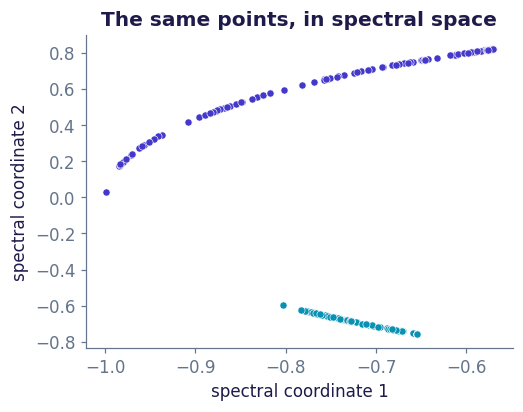

In [8]:
U = eigvecs[:, :N_CLUSTERS]                         # k smallest eigenvectors
T = U / np.linalg.norm(U, axis=1, keepdims=True)    # row-normalise (NJW)

df["spec_coord_1"] = T[:, 0]
df["spec_coord_2"] = T[:, 1]
display(df[["x1", "x2", "true_label", "spec_coord_1", "spec_coord_2"]].head())

fig, ax = plt.subplots(figsize=(5, 3.7))
for c in (0, 1):
    sub = df[df.true_label == c]
    ax.scatter(sub.spec_coord_1, sub.spec_coord_2, c=CLUSTER[c], s=22,
               edgecolors="white", linewidths=0.4)
ax.set(xlabel="spectral coordinate 1", ylabel="spectral coordinate 2",
       title="The same points, in spectral space")
clean(ax)
plt.show()

## Step 7 — Cluster, then map back

Run ordinary k-means in the spectral space — the same algorithm from Step 0, but now the geometry is on its side. Then carry each label back to the original point it came from.

Same k-means at the start and the end. All the work was in changing the coordinates.

*Data:* `df` gains its last column, `spectral_label`. The master frame is now complete — every point with its coordinates, degree, spectral coordinates, and all three label sets — and the crosstab against `true_label` shows two clean blocks.

,x1,x2,true_label,kmeans_raw_label,degree,spec_coord_1,spec_coord_2,spectral_label
0,0.797294,0.629069,0,1,11.5,-0.877383,0.479791,1
1,1.062417,0.161677,0,1,10.5,-0.979248,0.202666,1
2,-0.703381,0.686154,0,0,10.0,-0.594504,0.804093,1
3,-0.953015,0.174334,0,0,12.0,-0.570937,0.820994,1
4,-0.984274,0.430205,0,0,9.0,-0.577013,0.816735,1


spectral,0,1
true,,
0,0,120
1,120,0


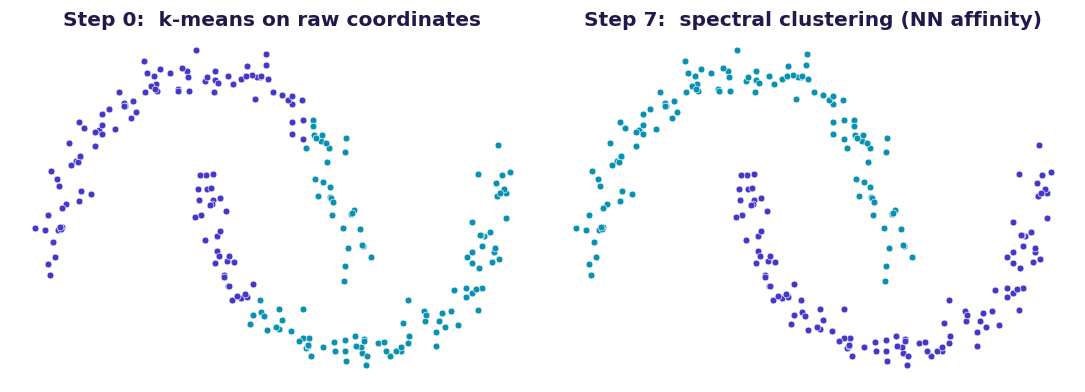

In [9]:
labels = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0).fit_predict(T)
df["spectral_label"] = labels

display(df.head())
display(pd.crosstab(df.true_label, df.spectral_label,
                    rownames=["true"], colnames=["spectral"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7))
for c in (0, 1):
    axes[0].scatter(*X[km_raw == c].T, c=CLUSTER[c], s=20,
                    edgecolors="white", linewidths=0.4)
    axes[1].scatter(*X[labels == c].T, c=CLUSTER[c], s=20,
                    edgecolors="white", linewidths=0.4)
axes[0].set(title="Step 0:  k-means on raw coordinates", xticks=[], yticks=[])
axes[1].set(title="Step 7:  spectral clustering (NN affinity)", xticks=[], yticks=[])
for ax in axes:
    clean(ax, spines=("top", "right", "left", "bottom"))
plt.tight_layout()
plt.show()

## The whole pipeline

The eight beats, wrapped in one function — a sparse, nearest-neighbour spectral clustering that mirrors `cuml.cluster.SpectralClustering` and scikit-learn's `affinity='nearest_neighbors'`. As a sanity check we run all three and compare to the ground truth with the adjusted Rand index (`1.0` = identical clustering, `0.0` = random).

*Data:* `df_results` collects the scores — one row per method.

In [10]:
from sklearn.cluster import SpectralClustering
from sklearn.metrics import adjusted_rand_score

def spectral_clustering(X, n_clusters=2, n_neighbors=10):
    """Normalized spectral clustering with nearest-neighbour affinity, from scratch.

    Mirrors the construction in cuml.cluster.SpectralClustering and
    sklearn's SpectralClustering(affinity='nearest_neighbors').
    """
    C = kneighbors_graph(X, n_neighbors=n_neighbors, include_self=True)
    W = (0.5 * (C + C.T)).tocsr()                              # symmetric NN affinity
    degree = np.asarray(W.sum(axis=1)).ravel()
    D_inv_sqrt = sp.diags(1.0 / np.sqrt(degree))
    L_sym = (sp.eye(W.shape[0]) - D_inv_sqrt @ W @ D_inv_sqrt).tocsr()   # normalized Laplacian
    k = min(n_clusters + 3, W.shape[0] - 1)                    # a few extra for solver stability
    eigvals, eigvecs = eigsh(L_sym, k=k, which="SA")           # truncated sparse eigensolver
    U = eigvecs[:, np.argsort(eigvals)][:, :n_clusters]        # n_clusters smallest
    T = U / np.linalg.norm(U, axis=1, keepdims=True)           # row-normalise
    return KMeans(n_clusters=n_clusters, n_init=10, random_state=0).fit_predict(T)

ours = spectral_clustering(X, n_clusters=N_CLUSTERS, n_neighbors=N_NEIGHBORS)
ref = SpectralClustering(n_clusters=N_CLUSTERS, affinity="nearest_neighbors",
                         n_neighbors=N_NEIGHBORS, random_state=0).fit_predict(X)

df_results = pd.DataFrame({
    "method": ["k-means (raw)",
               "spectral, NN affinity (from scratch)",
               "spectral, NN affinity (scikit-learn)"],
    "ARI_vs_truth": [
        adjusted_rand_score(y, df.kmeans_raw_label),
        adjusted_rand_score(y, ours),
        adjusted_rand_score(y, ref),
    ],
})
display(df_results)

,method,ARI_vs_truth
0,k-means (raw),0.214492
1,"spectral, NN affinity (from scratch)",1.000000
2,"spectral, NN affinity (scikit-learn)",1.000000


## The same pipeline on the GPU — cuML

`cuml.cluster.SpectralClustering` *is* this pipeline: it builds a nearest-neighbour affinity, forms the normalized Laplacian, runs a Lanczos eigensolver, and clusters the embedding — all on the GPU. With `affinity='nearest_neighbors'` (the default) and a matching `n_neighbors`, it is a drop-in for the from-scratch function above.

The cell below runs it if `cuml` + `cupy` and a GPU are available, and otherwise no-ops with a note — so the notebook executes anywhere, and the GPU path is one import away on a RAPIDS box.

In [11]:
try:
    import cupy as cp
    from cuml.cluster import SpectralClustering as cuSpectralClustering

    X_gpu = cp.asarray(X, dtype=cp.float32)
    cu = cuSpectralClustering(n_clusters=N_CLUSTERS, affinity="nearest_neighbors",
                              n_neighbors=N_NEIGHBORS, random_state=0)
    cu.fit(X_gpu)
    cu_labels = cp.asnumpy(cu.labels_)

    df_results.loc[len(df_results)] = ["spectral, NN affinity (cuML, GPU)",
                                       adjusted_rand_score(y, cu_labels)]
    print("cuML SpectralClustering ran on GPU.")
    display(df_results)
except Exception as e:                       # cuML / cupy / GPU not present
    print(f"cuML not available in this environment -> skipping GPU run.\n  ({type(e).__name__}: {e})")
    print("On a RAPIDS install, this cell runs the identical pipeline on the GPU.")

cuML not available in this environment -> skipping GPU run.
  (ModuleNotFoundError: No module named 'cupy')
On a RAPIDS install, this cell runs the identical pipeline on the GPU.


## Summary of eight concepts

| beat | step | what it does | data |
|:---:|---|---|---|
| 0 | k-means fails | establishes why distance-based clustering is not enough | `df.kmeans_raw_label` |
| 1 | similarity from neighbours | a point's similars are its k nearest | `df_neighbors` |
| 2 | build the graph | every point's kNN edges, three constructions compared | `df_edges` |
| 3 | NN affinity matrix `W` | sparse, symmetric; the block-diagonal structure appears | `df_W` |
| 4 | Laplacian `L = D - W` | repackage connectivity for eigen-analysis (still sparse) | `df_L`, `df_Lsym`, `df.degree` |
| 5 | eigenvectors + eigengap | truncated sparse eigensolver; the spectrum reveals `k` | `df_spectrum` |
| 6 | spectral embedding | re-coordinate points into separable space | `df.spec_coord_1/2` |
| 7 | cluster & map back | k-means in that space, labels mapped home | `df.spectral_label` |

Spectral clustering rewrites the data in coordinates where structure becomes geometry — then clusters the geometry. The master `df` is the receipt: it starts as two raw coordinate columns and ends carrying every transformation the pipeline applied.

If you keep three pictures from this notebook, keep these: **the block-diagonal `W`** (Step 3), **the eigengap** (Step 5), and **the moons separating in the embedding** (Step 6). They carry the whole intuition.

### Mapping to cuML at scale

This notebook already runs the *sparse* path, so the move to GPU is mechanical, not structural:

| from-scratch step | cuML / RAPIDS |
|---|---|
| `kneighbors_graph` + symmetrise | `cuml.neighbors.NearestNeighbors` → kNN graph (built inside `SpectralClustering`) |
| sparse `L_sym` | formed internally from the NN affinity |
| `scipy.sparse.linalg.eigsh` | Lanczos eigensolver on the GPU |
| `KMeans` on the embedding | `cuml.cluster.KMeans` (used internally) |
| whole pipeline | `cuml.cluster.SpectralClustering(affinity='nearest_neighbors', n_neighbors=...)` |

For the embedding alone, `cuml.manifold.spectral_embedding` exposes Steps 3–6 directly. The cost centres are the kNN build and the eigensolve — both of which are exactly what the GPU implementations accelerate.